# Graphene structures and RGF


This notebook implements the Landauer-Buttiker method to calculate electronic transmission, using the Green function approach.

The basic ideas are:
- define the systen geometrym and then split the system into left and right leads, and device region
- position everything correctly!
- define the periodic cell and lattice vector for each lead
- calculate the hamiltonian for each part of the system
- calculate the hopping matrices between each lead and the device, and between each each repeated cell in the leads
- use the Rubio-Sancho algorithm to efficiently find the Surface Green's Function of each lead
- build the device system block-by-block (recursively), finishing where the leads will be added.
- calculating transmission using the Trace formula


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import distance_matrix
from scipy.spatial import cKDTree

## definitions
dd = 1/np.sqrt(3) + 0.01  ## threshold for connections
eta= 1E-5

The functions below:
- define a simple device geometry (and return its distance matrix)
- calculate the self energies for the leads, given the periodic cell and lattice vectors
- split a (device) system into individual cells, based on its connectivity and a supplied "starting cell". (This is the cell to which the leads will be added, and becomes the final cell in the actual transport calculation)
- finds lists of neighbours within a system, or between two systems

In [6]:
# Functions

def blank_rect_lattice(size_zz, size_ac, origin):
    '''Generates an initial graphene segment, and returns coordinates, sublattices, and distance matrix'''
    #size_(zz/ac) = length of the blank lattice in the zigzag and armchair directions, ie size*size square
    #origin = starting point for generation, a vector so a 1*2 matrix. Usually (0,0)
    
    
    cellsubs=np.array((1, -1, 1, -1))
    offsets = np.array( [  [0.5, -1/(2*np.sqrt(3))],[0, 0], [0, 1/np.sqrt(3)], [0.5, np.sqrt(3)/2] ])
    
    vectorzz=np.array([1,0])
    vectorac=np.array([0, np.sqrt(3)])

    
    ilist, jlist = np.arange(size_zz), np.arange(size_ac)
    isize, jsize=len(ilist), len(jlist)
    ilist, jlist = np.meshgrid(ilist, jlist)
    ilist, jlist = ilist.flatten(), jlist.flatten()

    allcoords = np.empty([len(offsets)*len(ilist), 2])
    
    subs = np.empty(len(offsets)*len(ilist))
        
    for a, (i, j) in enumerate(zip(ilist, jlist)):
        for b, off in enumerate(offsets):
            allcoords[len(offsets)*a+b] = np.array(origin) + i*np.array(vectorzz) + j*np.array(vectorac) + off
            subs[len(offsets)*a+b] = cellsubs[b]
        
    dmat = distance_matrix(allcoords, allcoords)

    return allcoords, subs, dmat   


# Function for calculating the surface GFs from the leads (left and right)
# Not Rubio-Sancho, but should be equivalent..
# Doubles the lead each time, and gets both lead SGFs at the same time
def surface(H_00, V1, V2, epsilon, energy, eta):
    ii = np.identity(len(H_00), dtype = 'complex128')
    g00 = np.linalg.inv(np.dot(ii, energy + eta*1j) - H_00)
    g11old, gLLold, g1Lold, gL1old = g00, g00, g00, g00
    errL, errR = 1, 1
    
    while ((errL > epsilon) | (errR > epsilon)):
        t1 = np.dot(g11old, V2)
        t2 = np.dot(gLLold, V1)
        A = np.linalg.multi_dot([np.linalg.inv(ii - np.dot(t2, t1)), t2, g1Lold])
        B = np.linalg.multi_dot([np.linalg.inv(ii - np.dot(t1, t2)), t1, gL1old])
        gLLnew = gLLold + np.linalg.multi_dot([gL1old, V2, A])
        g11new = g11old + np.linalg.multi_dot([g1Lold, V1, B])
        g1Lnew = np.linalg.multi_dot([g1Lold, V1, g1Lold + np.dot(t1, A)])
        gL1new = np.linalg.multi_dot([gL1old, V2, gL1old + np.dot(t2, B)])
        # Biggest error on either side
        errL = np.abs((g11new - g11old)).flatten().max()
        errR = np.abs((gLLnew - gLLold)).flatten().max()
        # Update GFs
        g11old, gLLold, gL1old, g1Lold = g11new, gLLnew, gL1new, g1Lnew
    return gLLold, g11old


# Splits a coordinate list into cells, given the indices of a "final cell" (starting_set here)
def SplitLattice(coords, starting_set, dist):
    
    cells_other = []
    
    tree = cKDTree(coords)
    neighbours = tree.query_ball_tree(tree, dist) 
    
    unassigned = list(np.arange(len(coords)))
    
    cells_other = [starting_set]
    
    while len(unassigned) > 0:
        unassigned = list( set(unassigned) - set(cells_other[-1]) )
        temp = [i for j in cells_other[-1] for i in neighbours[j]]
        new = list(set(unassigned) & set(temp)) 
        if (len(new) > 0):
            cells_other.append(new) 
            
    cells_other = cells_other[::-1]
    return cells_other


#functions to get the corresponding hamiltonian indices using KDtrees
def get_full_pairs(tree, dist):
    pairs = list(tree.query_pairs(dist)) 
    all_pairs=[]
    for pair in pairs:
        all_pairs.append(pair[::-1])
    all_pairs = np.array(pairs + all_pairs)
    return all_pairs

def get_full_pairs2(tree, tree2, dist):
    data = list(tree.query_ball_tree(tree2, dist)) 
    # convert to lists of pairs
    pairs = [(row_idx, item) for row_idx, row in enumerate(data) for item in row]
    
    if len(pairs) == 0:
        pairs = np.empty([0,2])
    return  np.array(pairs )

Simple example of a finite ribbon segment.   
The commented out section allows you to etch a hole 

In [9]:
# Generate a device region


z_index = 20  ## must be even!  ## index of the zigzag ribbon in standard form, e.g the N in N-ZGNR
                                ## more work needed to generate an odd-index ribbon..
d_length = 30 # device length in unit cells


# Coordinates, sublattices, and distance matrix of device region
a, subs, dmat = blank_rect_lattice(d_length, z_index/2, (0.0, 0.0))


# # Binary adjacency matrix: 1 if connected, 0 if not
# adj = np.isclose(dmat, 1/np.sqrt(3)).astype(int)
# # Count the number of connections for each atom
# num_neighbors = adj.sum(axis=1)
# # Get indices of atoms with 2 neighbors
# edge_atoms = np.where(num_neighbors == 2)[0]

# # Randomly select % of edge atoms to remove
# num_to_remove = max(2, int(0.25 * len(edge_atoms)))  
# remove_atoms = np.random.choice(edge_atoms, size=num_to_remove, replace=False)

# # Keep the rest
# keep_atoms = np.array([i for i in range(len(a)) if i not in remove_atoms])
# a, subs, dmat = a[keep_atoms], subs[keep_atoms], dmat[np.ix_(keep_atoms, keep_atoms)]



# # The following three lines etch a hole. Try to understand how this works!
# circ_x, circ_y, circ_r = 5.0, 3.0, 1.5
# sites =  np.where ( (a[:,0] - circ_x )**2 + (a[:,1] - circ_y )**2 > circ_r**0.5)[0]
# a, subs, dmat  = a[sites], subs[sites], dmat[np.ix_(sites, sites)]

#generate device hamiltonian
h_dev = np.isclose(distance_matrix(a, a), 1/np.sqrt(3))*(-1.0)

# onsite energies of each site
onsites = np.zeros_like(subs, dtype=float)

# # uncomment this to add random potentials ("onsite disorder") to the system
# onsites = np.random.rand(len(subs))

Plot the system

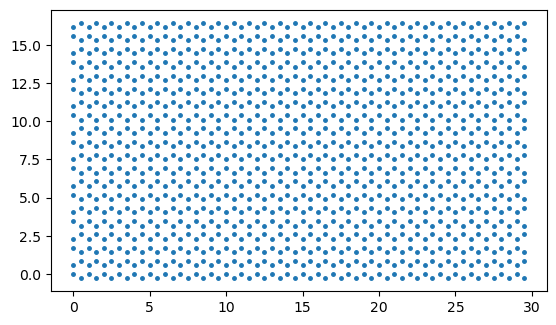

In [56]:
fig, ax=plt.subplots()
ax.plot(a[:,0], a[:,1], 'o',ms=2.5)
#ax.plot(a[sites,0], a[sites,1], 'o')

ax.set_aspect('equal')
plt.show()

The next cell defines the leads.   
We do this by first creating a similar system to the device, but with length 1.   
Then we define the shifted x-coordinates to move them into place.   
Check the plot underneath to see this more clearly, noting that the position of the right lead depends on the length of the system!

In [14]:
# create leads
# e.g. a transport unit cell from each lead which is nearest the device

t_a, t_subs, t_dmat = blank_rect_lattice(1, z_index/2, (0.0, 0.0))


# x and y coords of each lead (shifted relative to device) (y is the same for each)
xl = t_a[:,0]-1.0
xr = t_a[:,0] + (d_length)*1.0
yl = t_a[:,1]


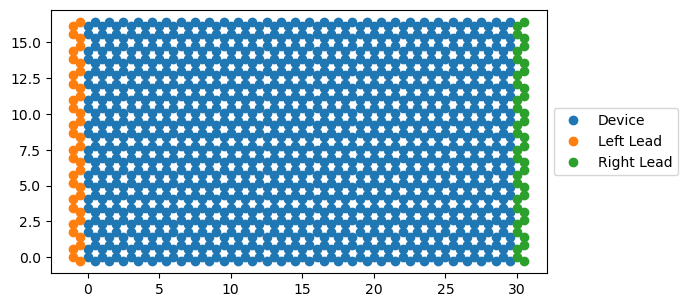

In [18]:
fig, ax=plt.subplots()
ax.plot(a[:,0], a[:,1], 'o', label='Device')

ax.plot(xl, yl, 'o', label = 'Left Lead')
ax.plot(xr, yl, 'o', label = 'Right Lead')
ax.legend(bbox_to_anchor=(1, 0.5), loc=6)
ax.set_aspect('equal')
plt.show()

The code below create the Hamiltonian matrix for the cell defining the lead, and the "left-to-right" matrix connecting two neighbouring cells.


In [20]:
# generate lead hamiltonian and VLR matrices
# same for both leads (might not always be the case!)

#lead H
h_lead = np.isclose(distance_matrix(np.array((xl, yl)).T, np.array((xl, yl)).T), 1/np.sqrt(3))*(-1.0)

# lead VLR
vlr_lead = np.isclose(distance_matrix(np.array((xl, yl)).T, np.array((xl+1, yl)).T), 1/np.sqrt(3))*(-1.0)

cKDTrees are useful for finding lists of neighbours.    
The example underneath uses them to plot all the nearest-neighbour pairs (i.e. C-C bonds) in the device

In [23]:
# generate 'ckdtrees' for the device and lead systems
# this uses a scipy package, and they can be queried later to quickly find pairs of sites that are neighbours, etc
# the get_full_pairs() and get_full_pairs2() functions above are quick ways of doing this!

ltree = cKDTree(np.array((xl, yl)).T)
rtree = cKDTree(np.array((xr, yl)).T)
dtree= cKDTree(a)


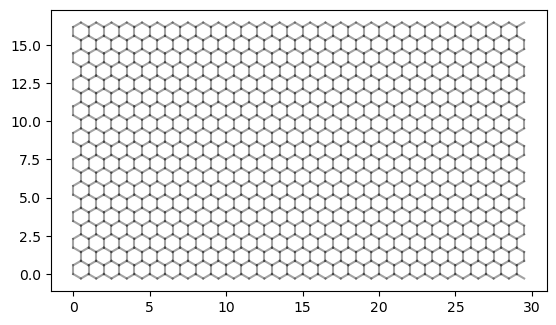

In [25]:
#example

# find pairs of atoms in device
d_pairs = get_full_pairs(dtree, dd)

# use to plot all the NN bonds in system
fig, ax=plt.subplots()
# ax.plot(a[:,0], a[:,1], 'o') - plot atoms as dots 
[ax.plot( [a[dp[0],0], a[dp[1],0]], [a[dp[0],1], a[dp[1],1]], 'k', alpha=0.2) for dp in d_pairs]

ax.set_aspect('equal')
plt.show()

The next two cells find which sites in the device connect to each lead.  
These site indices will be needed when we want to add the leads, and they also together define our "starting cell" for calculations.

In [28]:
# find the sites in the device that connect to the leads
dev_l_pairs =  get_full_pairs2(dtree, ltree, dd)
dev_r_pairs =  get_full_pairs2(dtree, rtree, dd)
dev_sites_l = dev_l_pairs[ :, 0]
dev_sites_r = dev_r_pairs[:,0]

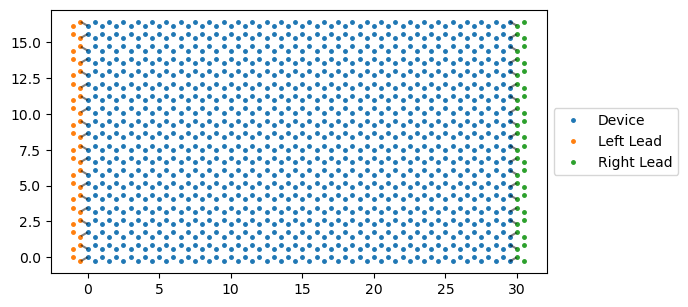

In [66]:
fig, ax=plt.subplots()
ax.plot(a[:,0], a[:,1], 'o',ms=2.5, label='Device')

ax.plot(xl, yl, 'o',ms=2.5, label = 'Left Lead')
ax.plot(xr, yl, 'o',ms=2.5, label = 'Right Lead')

# device to left lead connections
[ax.plot( [a[dp[0],0], xl[dp[1]]], [a[dp[0],1], yl[dp[1]]], 'k--',ms=2.5, alpha=0.5) for dp in dev_l_pairs]

# device to right lead connections
[ax.plot( [a[dp[0],0], xr[dp[1]]], [a[dp[0],1], yl[dp[1]]], 'k--',ms=2.5, alpha=0.5) for dp in dev_r_pairs]


ax.legend(bbox_to_anchor=(1, 0.5), loc=6)
ax.set_aspect('equal')
plt.show()

Now we're going to split the device into cells, by putting the sites that connect to the L and R leads in the last cell and building backwards.   
The "SplitLattice" function will do this for us, populating the N+1 cell from all sites that connect to cell N that are not yet allocated to a cell.   
(This function also reverses the cell order, so it is ready for RGF methods!)   
This will not give us the best splitting (why not?), but it will do for now!  

In [33]:
starting_cell = list(np.concatenate([dev_sites_l, dev_sites_r]))
cells =SplitLattice(a, starting_cell, dd)

# These indices are used later
# They keep track of which sites in the final cell link to the each lead
llead_ind = np.arange(len(dev_sites_l))
rlead_ind = np.arange(len(dev_sites_r)) + len(dev_sites_l)

# 'cells' now contains a list of lists, e.g. [[atoms in cell 0], [atoms in cell 1],  ... etc.] 
# uncomment to see this explicitly
print(cells)

[[896, 899, 901, 902, 776, 779, 781, 782, 656, 659, 661, 662, 536, 539, 541, 542, 416, 419, 421, 422, 296, 299, 301, 302, 176, 179, 181, 182, 56, 59, 61, 62, 1136, 1139, 1141, 1142, 1016, 1019, 1021, 1022], [897, 898, 900, 903, 777, 778, 780, 783, 657, 658, 660, 663, 537, 538, 540, 543, 417, 418, 420, 423, 297, 298, 300, 303, 177, 178, 180, 183, 57, 58, 60, 63, 1137, 1138, 1140, 1143, 1017, 1018, 1020, 1023], [1025, 1026, 772, 775, 905, 906, 652, 655, 785, 786, 532, 535, 665, 666, 412, 415, 545, 546, 292, 295, 425, 426, 172, 175, 305, 306, 52, 55, 185, 186, 65, 66, 1132, 1135, 1012, 1015, 1145, 1146, 892, 895], [1024, 1027, 773, 774, 904, 907, 653, 654, 784, 787, 533, 534, 664, 667, 413, 414, 544, 547, 293, 294, 424, 427, 173, 174, 304, 307, 53, 54, 184, 187, 64, 67, 1133, 1134, 1013, 1014, 1144, 1147, 893, 894], [768, 771, 1029, 1030, 648, 651, 909, 910, 528, 531, 789, 790, 408, 411, 669, 670, 288, 291, 549, 550, 168, 171, 429, 430, 48, 51, 309, 310, 189, 190, 69, 70, 1128, 1131, 1008

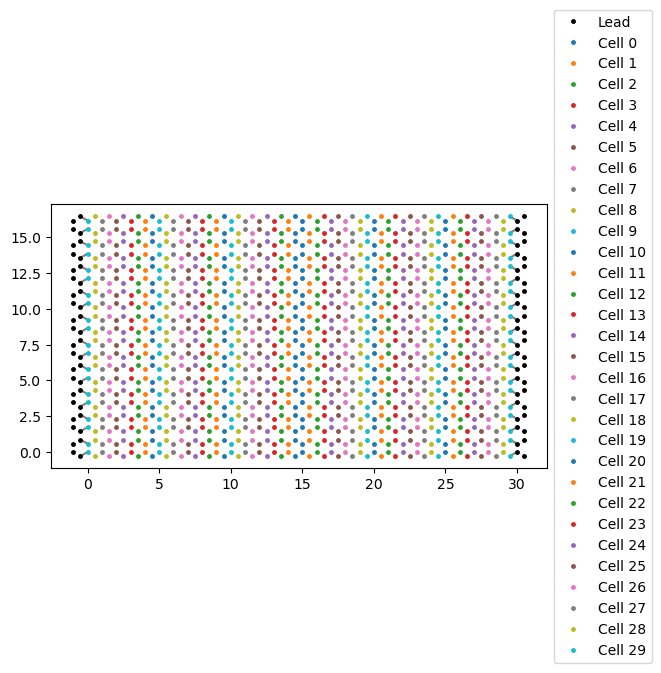

In [64]:
# plot the different cells
fig, ax=plt.subplots()

ax.plot(xl, yl, 'ko',ms=2.5 ,label = 'Lead')
ax.plot(xr, yl, 'ko',ms=2.5)

# device to left lead connections
[ax.plot( [a[dp[0],0], xl[dp[1]]], [a[dp[0],1], yl[dp[1]]], 'k--',ms=2.5, alpha=0.5) for dp in dev_l_pairs]

# device to right lead connections
[ax.plot( [a[dp[0],0], xr[dp[1]]], [a[dp[0],1], yl[dp[1]]], 'k--',ms=2.5, alpha=0.5) for dp in dev_r_pairs]

# plot sites in each cell
for i, cell in enumerate(cells):
    ax.plot(a[cell,0], a[cell, 1], 'o',ms=2.5, label='Cell '+str(i))
    
ax.legend(bbox_to_anchor=(1, 0.5), loc=6)
ax.set_aspect('equal')
plt.show()

The final hamiltonian terms we need are those connecting the leads and the device.   

*A technical note*: the atom indicing is a bit tricky here. 
When we add the leads to the device, we deal with a matrix only containing the final cell.   
Therefore, these matrices will not indexed relative to the entire device, and we will need to keep track of how many device atoms are required for each lead, and where they begin!

In [68]:
# Generate the connection (sub)matrices between the device and leads
# These will be used later to calculate self energies 
# Note the dimensions and indexing here (for the device part) are NOT based on the full device!!
# Need to be careful when using these later!

# dev to L
vdevl_lead = np.isclose(distance_matrix(a[dev_sites_l], np.array((xl, yl)).T), 1/np.sqrt(3))*(-1.0)

# dev to R
vdevr_lead = np.isclose(distance_matrix(a[dev_sites_r], np.array((xr, yl)).T), 1/np.sqrt(3))*(-1.0)

The actual calculation part!
Some notes:

- everything is contained in a big loop over energy
- as Green functions depend on energy, these need to be calculated inside the loop
- (this is not the case for Hamiltonian matrix elements, which are the same for every energy, and were calculated above!)
- the 0th cell is done first (for each energy)
- ... and then all the other cells are added, in turn, in the inner loop
- the GF is updated at every stage, and corresponds to different atoms each time
- when the inner loop is complete, the GF matrix contains only atoms in the final cell
- to which we then add the "full" self-energy, consisting of that from each lead.
- and then calculate the transmission


In [71]:
# Calculate the transmission through the system for a range of energies

e_start, e_final, e_pts = 0.0, 1.2, 101
es = np.linspace(e_start, e_final, e_pts)

trans = np.zeros_like(es)

# Loop over energies
for bb, en  in enumerate(es):
    
     # find the surface Green's functions for the left and right leads
    SL, SR = surface(h_lead, vlr_lead, vlr_lead.T, 1E-7, en, eta)
    
    # self-energy "blocks" for each lead
    self_l = np.linalg.multi_dot([vdevl_lead, SL, np.conj(vdevl_lead.T)])
    self_r = np.linalg.multi_dot([vdevr_lead, SR, np.conj(vdevr_lead.T)])
    
    
    # Set up the first cell of the device
    
    # indices of sites in cell 0
    ind = cells[0]
    
    # Hamiltonian (hoppings only) of this cell
    H0 = h_dev[np.ix_(ind, ind)]
    
    # add onsite energies to the diagonal
    H0 += np.diag(onsites[ind])
        
    # an identity matrix the same size    
    ii = np.identity(len(H0), dtype = 'complex128')
    
    # the GF of the first cell
    # this is also the first "old edge" of the device that will be used in recursive process
    g_old = np.linalg.inv(np.dot(ii, en + eta*1j) - H0)
    


    # Build device recursively *without* adding leads
    for i in range(1, len(cells)):
    
        # site indices for new cell, and previous cell
        ind = cells[i]
        ind_m = cells[i - 1]

        # cell H and g (as for first cell)
        H0 = h_dev[np.ix_(ind, ind)]
        H0 += np.diag(onsites[ind])
        ii = np.identity(len(H0), dtype = 'complex128')
        g_ii = np.linalg.inv(np.dot(ii, en + eta*1j) - H0)


        # connection matrices    (use transposes for vrl)
        # lr means i-1 to i, not necessarily left-to-right
        VLR = h_dev[np.ix_(ind_m, ind)]

        # find the connected, new edge cell GF
        G_ii = np.dot(np.linalg.inv(ii - np.linalg.multi_dot([g_ii, np.conj(VLR.T), g_old, VLR])), g_ii)

        # replace g_old for the next step
        g_old = G_ii
            
    
    # Broadening (Gamma) matrices for each lead        
    Gamma_L = 1j*(self_l - np.conj(self_l.T))
    Gamma_R = 1j*(self_r - np.conj(self_r.T)) 


    # add self energies using dyson to get the fully connected GF of the last cell
    # here we combine the self energies for each lead into one larger matrix 
    full_self = np.zeros_like(g_old)
    full_self[np.ix_(llead_ind, llead_ind)] = self_l
    full_self[np.ix_(rlead_ind, rlead_ind)] = self_r

    ## apply dyson eqn
    ii = np.identity(len(g_old), dtype = 'complex128')
    full_g =  np.linalg.inv( ii - np.dot(g_old, full_self)).dot(g_old)


    # get the GLR block we need for transport from the full GF matrix
    GLR = full_g[np.ix_(llead_ind, rlead_ind)]

    # calculate trace
    trans[bb] = np.real(np.trace(np.linalg.multi_dot([np.conj(GLR.T), Gamma_L, GLR, Gamma_R])))
    

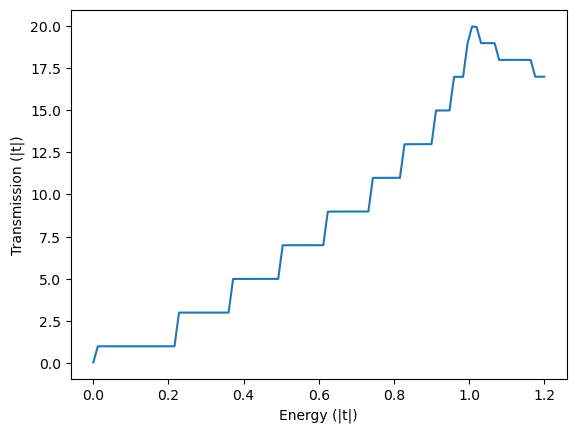

In [72]:
plt.plot(es, trans)
plt.xlabel('Energy (|t|)')
plt.ylabel('Transmission (|t|)')
plt.show()

In [ ]:
#DEVICE lEADS band structures explain transmition 

In [83]:
k= np.linspace(-np.pi, np.pi, 101)  # k-points

nbands= h_lead.shape[0]  # number of orbitals in the lead

bands = np.zeros((len(k), nbands), dtype=float)  # array to store eigenvalues

print(bands.shape)  


(101, 40)


In [85]:
#use eq bloch hamiltonian the eigenvalues at each k point 

for i, ki in enumerate(k):
  
    Hk = h_lead + vlr_lead * np.exp(1j*ki) + vlr_lead.conj().T * np.exp(-1j*ki)
    
    
    eigvals, eigvecs = np.linalg.eigh(Hk)
    
    
   
    bands[i, :] = np.sort(eigvals) 

print(bands[0, :])

print(bands)

[-1.0000000e+00 -1.0000000e+00 -1.0000000e+00 -1.0000000e+00
 -1.0000000e+00 -1.0000000e+00 -1.0000000e+00 -1.0000000e+00
 -1.0000000e+00 -1.0000000e+00 -1.0000000e+00 -1.0000000e+00
 -1.0000000e+00 -1.0000000e+00 -1.0000000e+00 -1.0000000e+00
 -1.0000000e+00 -1.0000000e+00 -1.0000000e+00 -9.9699421e-65
 -9.9699421e-65  1.0000000e+00  1.0000000e+00  1.0000000e+00
  1.0000000e+00  1.0000000e+00  1.0000000e+00  1.0000000e+00
  1.0000000e+00  1.0000000e+00  1.0000000e+00  1.0000000e+00
  1.0000000e+00  1.0000000e+00  1.0000000e+00  1.0000000e+00
  1.0000000e+00  1.0000000e+00  1.0000000e+00  1.0000000e+00]
[[-1.         -1.         -1.         ...  1.          1.
   1.        ]
 [-1.06209781 -1.05994131 -1.05639576 ...  1.05639576  1.05994131
   1.06209781]
 [-1.12422173 -1.12016665 -1.1134844  ...  1.1134844   1.12016665
   1.12422173]
 ...
 [-1.12422173 -1.12016665 -1.1134844  ...  1.1134844   1.12016665
   1.12422173]
 [-1.06209781 -1.05994131 -1.05639576 ...  1.05639576  1.05994131
  

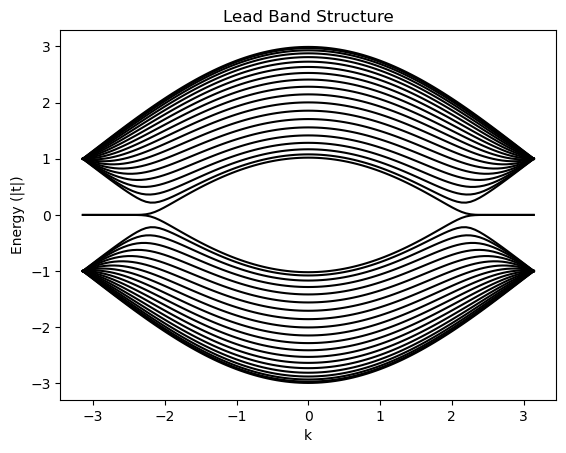

In [99]:
for n in range(nbands):
    plt.plot(k, bands[:, n],'k')
plt.xlabel('k')
plt.ylabel('Energy (|t|)')
plt.title('Lead Band Structure')
plt.show()

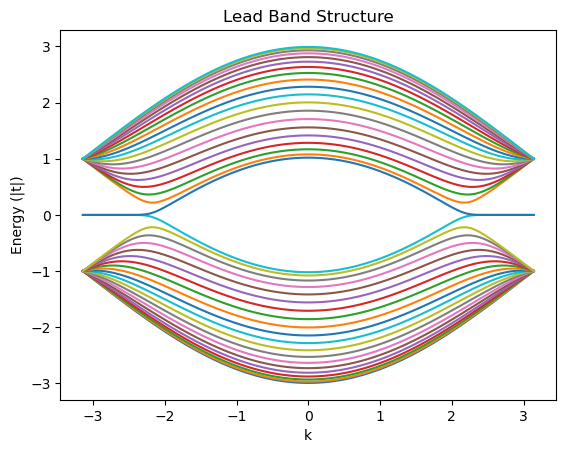

In [81]:


for n in range(nbands):
    plt.plot(k, bands[:, n])
plt.xlabel('k')
plt.ylabel('Energy (|t|)')
plt.title('Lead Band Structure')
plt.show()


/var/folders/mv/g7t2t7zs6zjdv1hksbybwd500000gn/T/ipykernel_97070/3136809009.py:30: RuntimeWarning: Mean of empty slice
  T_avgd = np.nanmean(Transmissions_combined4d, axis=0)


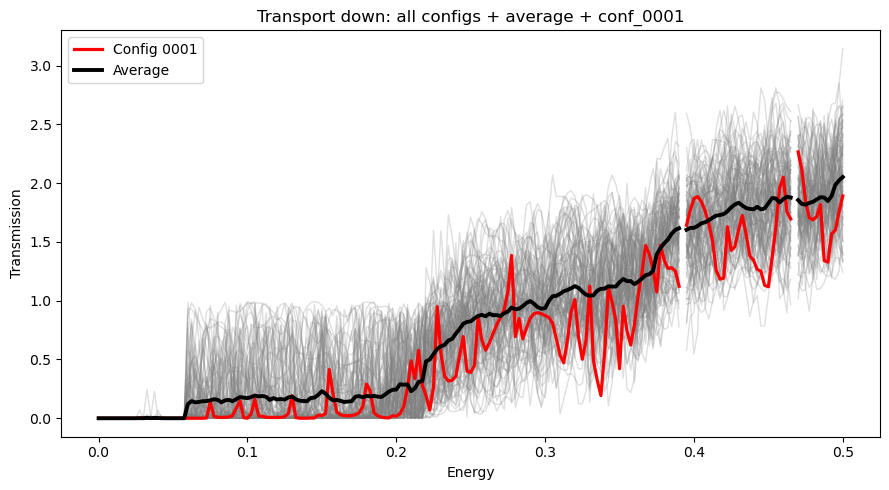

In [107]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import glob
# folder = Path("msystems/ZGNR_20_L90_p0.05_n100_20260330_154808")
folder = Path("msystems/ZGNR_20_L90_p0.02_n100_20260330_192717")
# ---- load all configs ----
all_files4d = sorted(folder.glob("conf_*_transport_results.npz"))

all_transmissions4d = []
energies = None

for f in all_files4d:
    try:   # <<< added this
        data = np.load(f)
        if energies is None:
            energies = data["energies"]        # same for all configs
        all_transmissions4d.append(data["trans_down"])
    except Exception as e:   # <<< added this
        print(f"Skipping bad file: {f.name} -> {e}")

Transmissions_combined4d = np.array(all_transmissions4d)   # (N_configs, N_energies)

# ---- load config 0001 explicitly ----
file_conf1d = folder / "conf_0001_transport_results.npz"
data1d = np.load(file_conf1d)
T_conf1d = data1d["trans_down"]

# ---- average ----
T_avgd = np.nanmean(Transmissions_combined4d, axis=0)

# ---- plot ----
plt.figure(figsize=(9,5))

# all configs: grey transparent
for i in range(Transmissions_combined4d.shape[0]):
    plt.plot(energies, Transmissions_combined4d[i],
             color="grey", alpha=0.25, lw=1)

# config 0001: red
plt.plot(energies, T_conf1d,
         color="red", lw=2.3, label="Config 0001")

# average: black
plt.plot(energies, T_avgd,
         color="black", lw=2.8, label="Average")

plt.xlabel("Energy")
plt.ylabel("Transmission")
plt.title("Transport down: all configs + average + conf_0001")
plt.legend()
plt.tight_layout()
plt.show()

In [91]:

k_index = 90             # pick a k-point
state_index = 1 


Hk = h_lead + vlr_lead * np.exp(1j*k[k_index]) + vlr_lead.conj().T * np.exp(-1j*k[k_index])
eigvals, eigvecs = np.linalg.eigh(Hk)

u_kn = eigvecs[:, state_index]       
weights = np.abs(u_kn)**2             


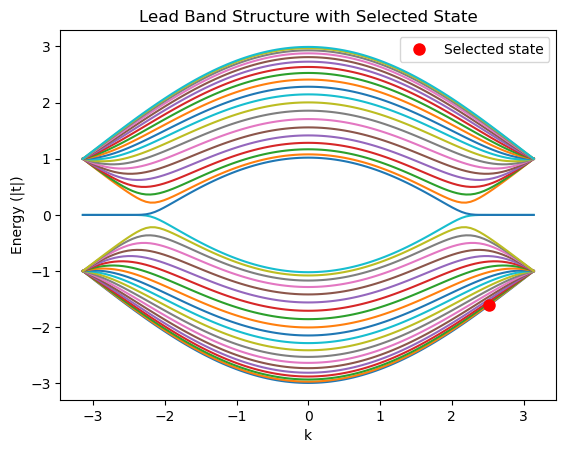

In [93]:
plt.figure()
for n in range(nbands):
    plt.plot(k, bands[:, n]) 
plt.plot(k[k_index], bands[k_index, state_index], 'ro', markersize=8, label='Selected state')
plt.xlabel('k')
plt.ylabel('Energy (|t|)')
plt.title('Lead Band Structure with Selected State')
plt.legend()
plt.show()



In [95]:
# H_device = h_dev + onsite energies
ii = np.identity(len(h_dev), dtype=complex)
en = 1  
eigvals, eigvecs = np.linalg.eigh(h_dev + np.diag(onsites))  

state_index = 1 
u_n = eigvecs[:, state_index]  
weights = np.abs(u_n)**2
weights /= np.max(weights)



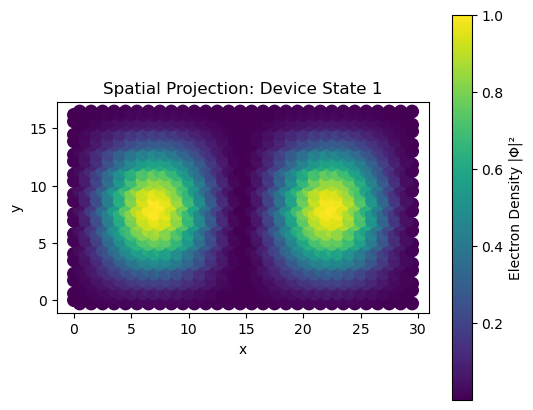

In [96]:
plt.figure(figsize=(6,5))
plt.scatter(a[:,0], a[:,1], c=weights, s=80, cmap='viridis')
plt.colorbar(label='Electron Density |Φ|²')
plt.xlabel('x')
plt.ylabel('y')
plt.title(f'Spatial Projection: Device State {state_index}')
plt.gca().set_aspect('equal')
plt.show()